# Setup

Making the necessary imports.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import os
from PIL import Image
from tqdm import tqdm

# from preprocessing.py
from preprocessing import (
    create_validation_split,
    get_dataset_statistics,
    augment_minority_classes,
    get_augmentation_pipeline_no_tensor,
    load_and_preprocess_image,
    letterbox,
    CATEGORIES_MAP,
)

# Data Preprocessing for Grain Disease Classification

This notebook documents all preprocessing steps applied to the grain dataset.

## Preprocessing Steps:
1. Remove the Impurities class
2. Image Resizing
3. Dataset Splitting
4. Class Imbalances Check

## Remove the Impurities Class
The impurity class for both maize and corn has almost the same content for its images (mainly small rocks or dirt that wasn't seperated during harvest). This may cause our models to not be able to differentiate between the classes for rice and maize. We thought of combining the impurity class for both of the grains, but due to the fact that there are some impurities in rice that are not present in maize (like the husk of the rice), we decided it was best not to merge the two. Instead, we decided to just focus on the disease classes for both of the grains for classification. 

We will remove both of the impurity class images for both of the grains due to this.

In [2]:
dataset_dir = "dataset/images"
grain_types = ["maize", "rice"]
splits = ["train", "test"]

In [3]:
import shutil

to_remove = "7_IM"

for grain_type in grain_types:
    for split in splits:
        target_dir = os.path.join(dataset_dir, grain_type, split, to_remove)

        if os.path.exists(target_dir):
            try:
                shutil.rmtree(target_dir)
                print(f"Folder {target_dir} succesfully removed")
            except OSError as e:
                print(f"Error: {target_dir} - {e}")
        else:
            print(f"Folder {target_dir} does not exist")

Folder dataset/images/maize/train/7_IM does not exist
Folder dataset/images/maize/test/7_IM does not exist
Folder dataset/images/rice/train/7_IM does not exist
Folder dataset/images/rice/test/7_IM does not exist


## Resize Image Aspect Ratio

The aspect ratio will be converted to 1:1 in order to make the images uniform. We will use a 1:1 aspect ratio as this is the one commonly used by many of the popular models like MobileNet and EfficientNet

In [4]:
# Count total images for progress bar
total_images = 0
for grain_type in grain_types:
    for split in splits:
        split_dir = os.path.join(dataset_dir, grain_type, split)
        if not os.path.exists(split_dir):
            continue
        for category in os.listdir(split_dir):
            category_dir = os.path.join(split_dir, category)
            if not os.path.isdir(category_dir):
                continue
            total_images += sum(
                1 for f in os.listdir(category_dir) if f.lower().endswith(".png")
            )

# Process images with progress bar
processed = 0
with tqdm(total=total_images, desc="Processing images") as pbar:
    for grain_type in grain_types:
        for split in splits:
            split_dir = os.path.join(dataset_dir, grain_type, split)
            if not os.path.exists(split_dir):
                continue

            # Iterate through categories
            for category in os.listdir(split_dir):
                category_dir = os.path.join(split_dir, category)
                if not os.path.isdir(category_dir):
                    continue

                for fname in os.listdir(category_dir):
                    if not fname.lower().endswith(".png"):
                        continue

                    path = os.path.join(category_dir, fname)

                    try:
                        img = Image.open(path).convert("RGB")
                        img_lb = letterbox(img)
                        img_lb.save(path, quality=95)  # overwrite
                    except Exception as e:
                        print(f"Failed on {path}: {e}")

                    pbar.update(1)

print("Image resizing complete!")

Processing images:   0%|          | 0/44962 [00:00<?, ?it/s]

Processing images: 100%|██████████| 44962/44962 [12:51<00:00, 58.26it/s] 

Image resizing complete!




## Validation Split Creation
<span style="color:red;">
We'll take 15% off from the training data to use as validation data.
- **Why not more?** We might starve the trianing data and harm the model's learning.
- **Why not less?** Our dataset has large imbalances, smaller splits would exacerbate variance for the minority classes and lead to unreliable estimates.

**Intuition:** "I'll spend enough to shake the hunger off now, not too much that I'll starve myself later from having no money."

</span>

In [4]:
print("Creating validation splits...")
maize_stats = create_validation_split("maize", val_ratio=0.15, random_state=42)
rice_stats = create_validation_split("rice", val_ratio=0.15, random_state=42)

Creating validation splits...
Validation split already exists for maize, skipping.
Validation split already exists for rice, skipping.


<span style="color:red;">

### Validation Split Visualization

In order to have a better look at the split, let's visualize it via a bar graph.
</span>

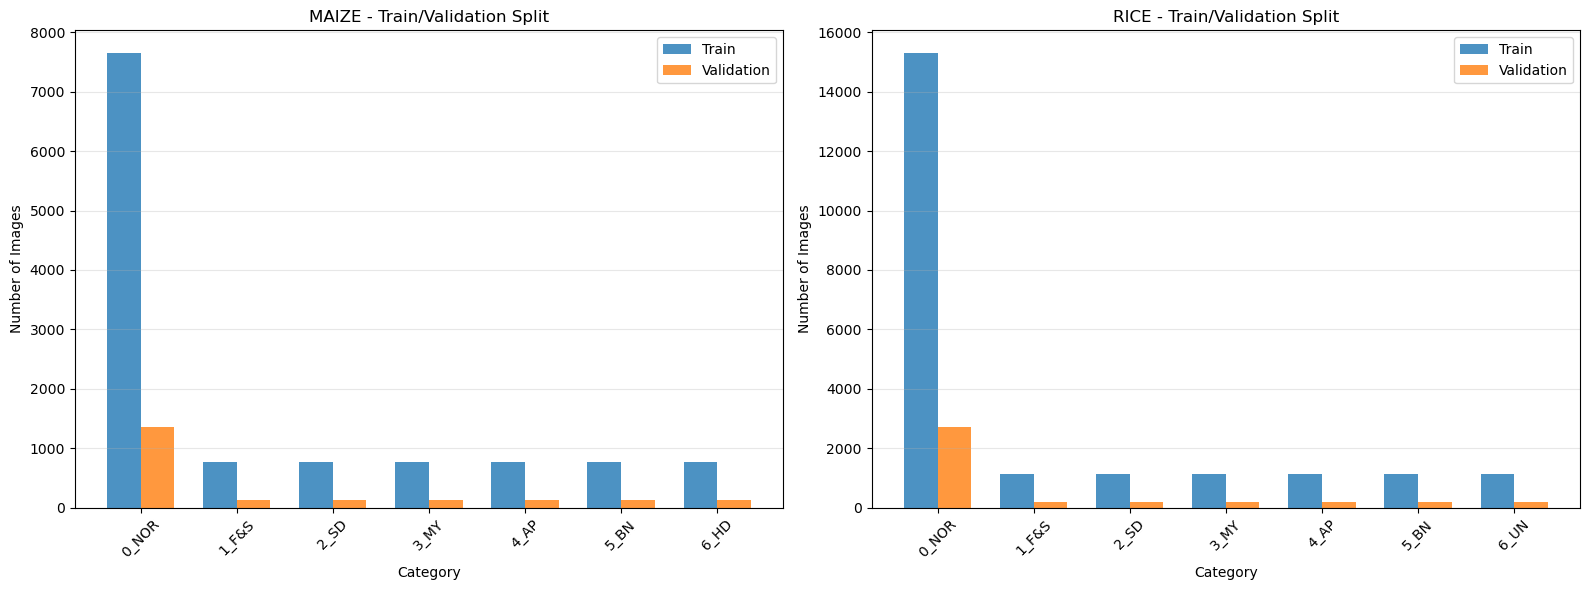

In [5]:
# If create_validation_split skipped (already exists), read counts from disk instead
def get_split_counts(grain, stats_from_function):
    if stats_from_function:
        return stats_from_function
    disk_stats = get_dataset_statistics(grain, splits=["train", "val"])
    result = {}
    for cat in CATEGORIES_MAP[grain]:
        result[cat] = {
            "train": disk_stats.get("train", {}).get(cat, 0),
            "val": disk_stats.get("val", {}).get(cat, 0),
        }
    return result


maize_counts = get_split_counts("maize", maize_stats)
rice_counts = get_split_counts("rice", rice_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (grain, counts) in enumerate([("maize", maize_counts), ("rice", rice_counts)]):
    if not counts:
        continue
    categories = list(counts.keys())
    train_counts = [counts[cat]["train"] for cat in categories]
    val_counts = [counts[cat]["val"] for cat in categories]
    x = np.arange(len(categories))
    width = 0.35
    axes[idx].bar(x - width / 2, train_counts, width, label="Train", alpha=0.8)
    axes[idx].bar(x + width / 2, val_counts, width, label="Validation", alpha=0.8)
    axes[idx].set_xlabel("Category")
    axes[idx].set_ylabel("Number of Images")
    axes[idx].set_title(f"{grain.upper()} - Train/Validation Split")
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(categories, rotation=45)
    axes[idx].legend()
    axes[idx].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Class Imbalance Check

Before augmenting, we look at the current image counts per category to see imbalances. 

**Intuition:** If some categories have far fewer images, the model will see them less during training and become biased toward the majority classes.

In [6]:
print("Class counts before augmentation:\n")
for grain in ["maize", "rice"]:
    print(f"{grain.upper()}:")
    stats = get_dataset_statistics(grain, splits=["train", "val", "test"])
    df = pd.DataFrame(stats).fillna(0).astype(int)
    print(df)
    train_counts = df["train"] if "train" in df.columns else pd.Series()
    if not train_counts.empty:
        print()
        print(
            f"Most common class:  {train_counts.idxmax()} ({train_counts.max()} images)"
        )
        print(
            f"Least common class: {train_counts.idxmin()} ({train_counts.min()} images)"
        )
        print(f"Imbalance ratio: {train_counts.max() / train_counts.min():.1f}x")
    print()

Class counts before augmentation:

MAIZE:
       train   val  test
0_NOR   7650  1350  1000
1_F&S    765   135   100
2_SD     765   135   100
3_MY     765   135   100
4_AP     765   135   100
5_BN     765   135   100
6_HD     765   135   100

Most common class:  0_NOR (7650 images)
Least common class: 1_F&S (765 images)
Imbalance ratio: 10.0x

RICE:
       train   val  test
0_NOR  15300  2700  2000
1_F&S   1136   200   150
2_SD    1148   202   150
3_MY    1148   202   150
4_AP    1148   202   150
5_BN    1140   201   150
6_UN    1135   200   150

Most common class:  0_NOR (15300 images)
Least common class: 6_UN (1135 images)
Imbalance ratio: 13.5x

